## モンテカルロ法による期待値計算
二通りの計算方法
- 一般的な方式（バッチ処理）
    $$
    V_n = \frac{1}{n} \sum_{t=1}^{n} s_t
    $$

- インクリメンタルな方式（オンライン）
    $$
    \begin{align*}
    V_{n} &= V_{n-1} + \frac{1}{n} (s_{n} - V_{n-1}) \\
    &= \frac{(n-1)V_{n-1} + s_{n}}{n}
    \end{align*}
    $$

## モンテカルロ法による方策評価
### 価値関数を求める
$$
v_\pi(s) = \mathbb{E}_\pi \left[ G|s \right]
$$
これをモンテカルロ法で求めると
$$
V_\pi(s) = \frac{1}{n} \sum_{i=1}^{n} G^{(i)} = \frac{1}{n} \sum_{t=1}^{n} \gamma^{t-1} R_{t-1}
$$
となる。

### すべての状態の価値関数を求める
状態が A -> B -> C -> (END) のように遷移するサンプルデータは、
- A -> B -> C -> (END)
- B -> C -> (END)
- C -> (END)
という３つのサンプルデータとしてみなすことができる。


## モンテカルロ法の実装
### エージェントクラスの実装

In [ ]:
from collections import defaultdict
import numpy as np
from common.gridworld import GridWorld
from typing import Any

In [ ]:
class RandomAgent:
    def __init__(self):
        self.gamma = 0.9
        self.action_size = 4

        random_actions = {0: 0.25, 1: 0.25, 2: 0.25, 3: 0.25}
        self.pi = defaultdict(lambda: random_actions)
        self.V = defaultdict(lambda: 0)
        self.cnts = defaultdict(lambda: 0)
        self.memory = []

    # 行動選択
    def get_action(self, state: Any) -> int:
        """
        Selects an action based on the current state using the policy.

        Parameters
        ----------
        state : Any
            current state

        Returns
        -------
        int
            selected action
        """
        action_probs = self.pi[state]
        actions = list(action_probs.keys())
        probs = list(action_probs.values())
        return np.random.choice(actions, p=probs)

    def add(self, state: Any, action: int, reward: float):
        """
        Adds a transition to the agent's memory.

        Parameters
        ----------
        state : Any
            current state
        action : int
            action taken
        reward : float
            reward received
        """

        data = (state, action, reward)  # (state, action, reward) のタプルを作成
        self.memory.append(data)

    def reset(self):
        """
        Resets the agent's memory.
        """
        self.memory.clear()

    def eval(self):
        """
        Evaluates the agent's memory and updates the value function.
        """
        G = 0
        for data in reversed(self.memory): # 逆向きにたどることで計算を効率化
            state, _, reward = data
            G = self.gamma * G + reward
            self.cnts[state] += 1
            # インクリメンタルな平均の更新式
            self.V[state] += (G - self.V[state]) / self.cnts[state]

In [1]:
env = GridWorld()
agent = RandomAgent()

episodes = 1000
for episode in range(episodes):
    state = env.reset()
    agent.reset()

    while True:
        action = agent.get_action(state)
        next_state, reward, done = env.step(action)

        agent.add(state, action, reward)
        if done:
            agent.eval()
            break

        state = next_state

env.render_v(agent.V)


KeyboardInterrupt



In [ ]:
# カウントのばらつきがある
agent.cnts

defaultdict(<function __main__.RandomAgent.__init__.<locals>.<lambda>()>,
            {(1, 3): 1752,
             (1, 2): 2611,
             (2, 2): 3980,
             (2, 1): 6285,
             (2, 0): 8753,
             (1, 0): 7177,
             (0, 0): 5348,
             (0, 2): 2159,
             (0, 1): 3619,
             (2, 3): 2732})

## モンテカルロ法による方策制御
### 評価と改善
**状態価値関数に関しての評価**
- 一般的な方式：$ V_n = \frac{1}{n} \sum_{i=1}^{n} G^{(i)} $
- インクリメンタルな方式：$ V_{n} = V_{n-1} + \frac{1}{n} (G^{(n)} - V_{n-1}) $

**行動価値関数に関しての評価**
- 一般的な方式：$ Q_n(s, a) = \frac{1}{n} \sum_{i=1}^{n} G^{(i)} $
- インクリメンタルな方式：$ Q_{n}(s, a) = Q_{n-1}(s, a) + \frac{1}{n} (G^{(n)} - Q_{n-1}(s, a)) $

## モンテカルロ法による方策制御の変更点

**$\epsilon$ - greedy 法**
- 一般的な方式：$ Q_n(s, a) = \frac{1}{n} \sum_{i=1}^{n} G^{(i)} $
- インクリメンタルな方式：$ Q_{n}(s, a) = Q_{n-1}(s, a) + \frac{1}{n} (G^{(n)} - Q_{n-1}(s, a)) $

### モンテカルロ法を使った方策制御の実装

In [11]:
# ε-greedy法
def greedy_probs(Q: defaultdict, state: Any, epsilon: float = 0, action_size: int = 4) -> dict:
    """
    Computes the action probabilities for a given state using an epsilon-greedy policy.

    Parameters
    ----------
    Q : defaultdict
        Action-value function
    state : Any
        Current state
    epsilon : float
        Epsilon value for exploration
    action_size : int
        Number of possible actions

    Returns
    -------
    dict
        Action probabilities
    """
    qs = [Q[(state, action)] for action in range(action_size)]
    max_action = np.argmax(qs)

    # 最大値の行動を1-ε + ε/4, 他をε/4にする
    base_prob = epsilon / action_size
    action_probs = {action: base_prob for action in range(action_size)}  #{0: ε/4, 1: ε/4, 2: ε/4, 3: ε/4}
    action_probs[max_action] += (1 - epsilon)
    return action_probs

class McAgent:
    def __init__(self):
        self.gamma = 0.9
        self.epsilon = 0.1
        self.alpha = 0.1
        self.action_size = 4

        random_actions = {0: 0.25, 1: 0.25, 2: 0.25, 3: 0.25}
        self.pi = defaultdict(lambda: random_actions)
        self.Q = defaultdict(lambda: 0)
        self.memory = []

    def get_action(self, state: Any) -> int:
        """
        Selects an action based on the current state using the policy.

        Parameters
        ----------
        state : Any
            current state

        Returns
        -------
        int
            selected action
        """
        action_probs = self.pi[state]
        actions = list(action_probs.keys())
        probs = list(action_probs.values())
        return np.random.choice(actions, p=probs)

    def add(self, state: Any, action: int, reward: float):
        """
        Adds a transition to the agent's memory.

        Parameters
        ----------
        state : Any
            current state
        action : int
            action taken
        reward : float
            reward received
        """
        data = (state, action, reward)
        self.memory.append(data)

    def reset(self):
        """
        Resets the agent's memory.
        """
        self.memory.clear()

    def update(self):
        """
        Evaluates the agent's memory and updates the value function.
        """
        G = 0
        for data in reversed(self.memory):
            state, action, reward = data
            G = self.gamma * G + reward
            key = (state, action)
            self.Q[key] += (G - self.Q[key]) * self.alpha # 指数移動平均を使う
            self.pi[state] = greedy_probs(self.Q, state, self.epsilon)

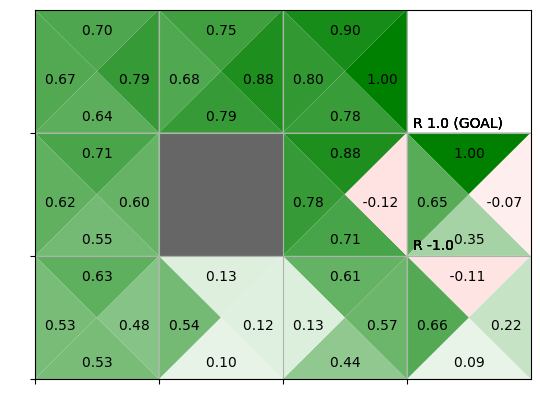

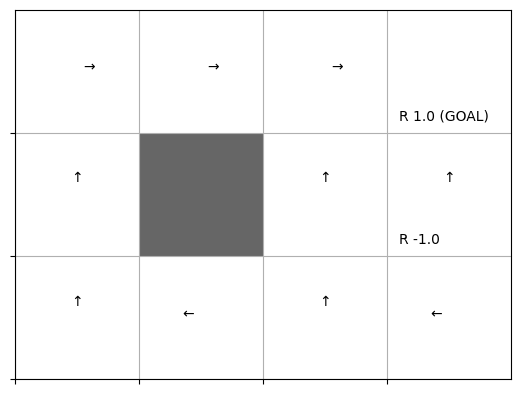

In [12]:
env = GridWorld()
agent = McAgent()

episodes = 100000
for episode in range(episodes):
    state = env.reset()
    agent.reset()

    while True:
        action = agent.get_action(state)
        next_state, reward, done = env.step(action)

        agent.add(state, action, reward)
        if done:
            agent.update()
            break

        state = next_state

env.render_q(agent.Q)

## 方策オフ型と重点サンプリング
ターゲット方策（評価・改善の対象となる方策）と挙動方策（エージェントが行動を起こす際に使う方策）が異なるかどうか？
- 方策オフ型（off-policy）**←ここではこっちを扱う**
- 方策オン型（on-policy）

挙動方策を取りながら、ターゲット方策を評価するにはどうしたら良いのか？→**重点サンプリングを用いる**

$$
\mathbb{E}_\pi [x] = \sum x \pi(x) = \sum x \frac{\pi(x)}{b(x)} b(x) = \mathbb{E}_b \left[ x \frac{\pi(x)}{b(x)} \right]
$$

In [15]:
class McOffPolicyAgent:
    def __init__(self):
        self.gamma = 0.9
        self.epsilon = 0.1
        self.alpha = 0.2
        self.action_size = 4

        random_actions = {0: 0.25, 1: 0.25, 2: 0.25, 3: 0.25}
        self.pi = defaultdict(lambda: random_actions)
        self.b = defaultdict(lambda: random_actions)
        self.Q = defaultdict(lambda: 0)
        self.memory = []

    def get_action(self, state):
        action_probs = self.b[state]
        actions = list(action_probs.keys())
        probs = list(action_probs.values())
        return np.random.choice(actions, p=probs)

    def add(self, state, action, reward):
        data = (state, action, reward)
        self.memory.append(data)

    def reset(self):
        self.memory.clear()

    def update(self):
        G = 0
        rho = 1

        for data in reversed(self.memory):
            state, action, reward = data
            key = (state, action)

            G = self.gamma * rho * G + reward
            self.Q[key] += (G - self.Q[key]) * self.alpha
            rho *= self.pi[state][action] / self.b[state][action]

            self.pi[state] = greedy_probs(self.Q, state, epsilon=0)
            self.b[state] = greedy_probs(self.Q, state, self.epsilon)

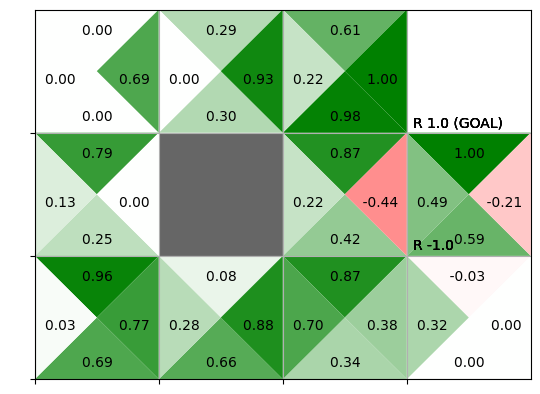

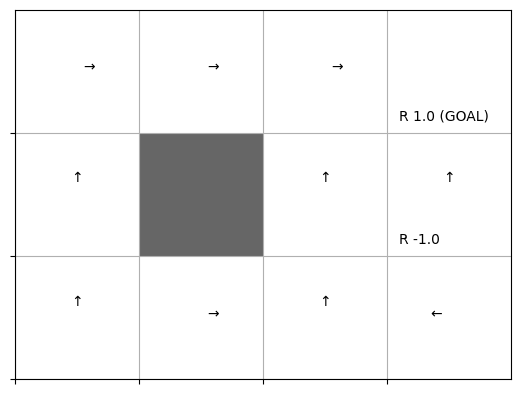

In [17]:
env = GridWorld()
agent = McOffPolicyAgent()

episodes = 10000
for episode in range(episodes):
    state = env.reset()
    agent.reset()

    while True:
        action = agent.get_action(state)
        next_state, reward, done = env.step(action)

        agent.add(state, action, reward)
        if done:
            agent.update()
            break

        state = next_state

env.render_q(agent.Q)